## 

### What Are Pandas
____

Pandas is a powerful data analysis library in Python that is especially well-suited for working with tabular data. In this tutorial, we'll explore its two core data structures: the DataFrame, which represents tabular data with labeled axes (rows and columns), and the Series, a one-dimensional labeled array.

We'll work with real-world weather data retrieved using the isd-fetch tool, which queries records from the National Centers for Environmental Information (NCEI). This dataset is ideal for our purposes—it combines DataFrame and Series structures and includes some irregularities that we'll clean up as part of our data preparation.

#### Throughout the tutorial, you'll learn how to:
* Load and explore raw data
* Clean and transform it for analysis
* Use Pandas to generate insights
* Create visualizations to better understand patterns and trends

#### Set Up a Python Virtural Envirnment

We'll begin by setting up your Python environment, creating a virtual environment, and installing the necessary packages. From there, we'll walk step-by-step through data analysis with Pandas, ending with a few visualizations to illustrate the power of what you've learned.

#### Getting Started

To get started you will need to have Python3 installed. We will also need to import the packages I recomend using a verirural envirmoment. To create a quick and esay Venv envrioment inyour termial run the following commands:

```bash

# Create a virtual environment named "pandas-tutorial-env"
python3 -m venv pandas-tutorial-env

# Activate the virtual environment (on macOS/Linux)
source pandas-tutorial-env/bin/activate

# If you're using Windows, activate with:
# pandas-tutorial-env\Scripts\activate

# To deactivate the virtual environment when you're done
deactivate

```
For more info on virtual enviroment and detailed install instructuion checkout this toturial [How to Set Up a Virtual Environment in Python – And Why It's Useful](https://www.freecodecamp.org/news/how-to-setup-virtual-environments-in-python/).

Once you have created your virtual environment, make sure that you select it as your Python kernel for the workbook.

#### Installing Packages

---

In this tutorial, we will be using packages that are not in Python's standard library. We will need to install these packages. Will need to install the following packages:
* [pandas](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)
* [geopandas](https://geopandas.org/en/stable/getting_started/introduction.html)
* [matplotlib](https://matplotlib.org/)
* [cartopy](https://scitools.org.uk/cartopy/docs/latest/)
* [isd-fetch](https://pypi.org/project/isd-fetch/)
* [pillow](https://pillow.readthedocs.io/en/stable/handbook/tutorial.html)

```bash
pip install pandas geopandas matplotlib cartopy isd-fetch pillow
```

In [1]:
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from pyisd import IsdLite
from functools import reduce

/home/jk/cityU/programing_for_computing_cs506/team-project/TP-01/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pick a Location

---

The first step is to choose a location to pull data from. In the example below, we define geo_box, a list of longitude and latitude coordinates. I’m based in the Pacific Northwest, so I’ve used a bounding box that covers that area.

You’re welcome to use the geo_box I’ve provided or feel free to modify the coordinates to focus on a different region. We'll also look at the option of querying data by country later if you’d rather query data by country.

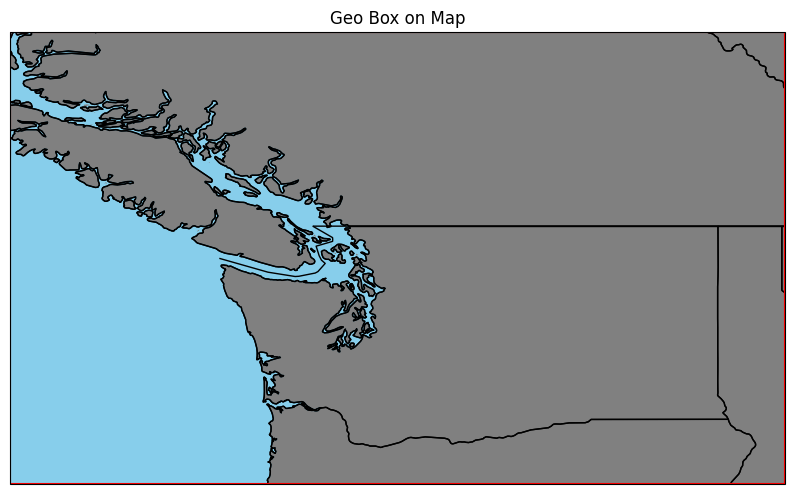

In [2]:

# Define the bounding box (lon_min, lon_max, lat_min, lat_max)
geo_box = [-128, -116, 45, 52]  # Example: part of Washington State

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.LAND, color='gray')
ax.add_feature(cfeature.OCEAN, color="skyblue")

# Set map extent to the geo box
ax.set_extent(geo_box, crs=ccrs.PlateCarree())

# Draw the bounding box
lon_min, lon_max, lat_min, lat_max = geo_box
ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    color='red',
    transform=ccrs.PlateCarree()
)

plt.title("Geo Box on Map")
plt.show()


Get Weather Data

--- 

Now that we've defined our geo_box, we can fetch weather data. We don't need a large dataset for this tutorial—so it's best to keep the time range and geographic area relatively small to speed up processing.

We'll use the isd-fetch tool from the NCEI (National Centers for Environmental Information), which gives us access to weather data from around the world—some of it dating back to the 1940s.

In the code below, we're retrieving data for January, limited to the geographic region defined by our geo_box in the previous step.

With as is it took about ten minuets to down load. 12687 records. Just enough time to make an other coffee and a snak.

In [3]:
# Initialize the client
isd = IsdLite(crs=4326, verbose=True)

# geo box around state of washington
pnw_data = isd.get_data(
    start='2025-01-01',
    end='2025-01-10',
    geometry=geo_box, #set geobox
    organize_by='field'
)

100%|██████████| 12687/12687 [15:49<00:00, 13.36it/s]


OK, lets dig into `pnw_data` and see what we've got:

In [4]:
print("pwn_data type: ", type(pnw_data))
print("pnw_data.columns: ", pnw_data.keys())
print("pnw_data['temp'] type", type(pnw_data['temp']))
print("pnw_data", pnw_data['temp'].index)
pnw_data['temp'].sample(4)


pwn_data type:  <class 'dict'>
pnw_data.columns:  dict_keys(['temp', 'dewtemp', 'pressure', 'winddirection', 'windspeed', 'skycoverage', 'precipitation-1h', 'precipitation-6h'])
pnw_data['temp'] type <class 'pandas.core.frame.DataFrame'>
pnw_data DatetimeIndex(['2025-01-01 00:00:00', '2025-01-01 01:00:00',
               '2025-01-01 02:00:00', '2025-01-01 03:00:00',
               '2025-01-01 04:00:00', '2025-01-01 05:00:00',
               '2025-01-01 06:00:00', '2025-01-01 07:00:00',
               '2025-01-01 08:00:00', '2025-01-01 09:00:00',
               ...
               '2025-01-10 14:00:00', '2025-01-10 15:00:00',
               '2025-01-10 16:00:00', '2025-01-10 17:00:00',
               '2025-01-10 18:00:00', '2025-01-10 19:00:00',
               '2025-01-10 20:00:00', '2025-01-10 21:00:00',
               '2025-01-10 22:00:00', '2025-01-10 23:00:00'],
              dtype='datetime64[ns]', length=240, freq='h')


,892570,889630,890550,890590,892660,892620,890630,890570,892510,890530,...,714170,718140,714060,718190,715840,718080,715580,713130,714210,715120
2025-01-06 23:00:00,NaN,5.0,3.7,NaN,-6.4,1.4,NaN,NaN,NaN,2.8,...,0.9,1.6,NaN,1.0,NaN,1.0,NaN,2.0,-1.9,0.5
2025-01-09 00:00:00,-1.2,1.0,0.3,0.0,-3.3,-0.6,1.6,3.7,4.0,4.5,...,-0.7,-2.4,-0.8,-0.4,0.1,-0.3,NaN,0.0,-0.7,-0.7
2025-01-08 18:00:00,0.4,6.5,4.9,0.0,-1.9,NaN,3.0,3.5,4.5,5.7,...,0.7,0.7,0.8,-0.7,3.8,0.6,NaN,4.0,-0.8,4.0
2025-01-10 12:00:00,-2.6,0.7,-2.0,-2.0,-3.8,-1.5,0.0,2.0,1.3,1.7,...,0.2,1.3,0.2,0.5,0.4,0.9,NaN,0.0,-5.8,0.6


#### Understanding the Data

---

* `pnw_data`: <class 'dict'>
* `pnw_data.keys()`: dict_keys(['temp', 'dewtemp', 'pressure', 'winddirection', 'windspeed', 'skycoverage', 'precipitation-1h', 'precipitation-6h'])
* `pnw_data['temp']`: type <class 'pandas.core.frame.DataFrame'>
* `pnw_data['temp'].index`: timestamps

We downloaded a Python dictionary with keys for temperature, dewtemp, pressure, wind direction, wind speed, sky coverage, one-hour precipitation, and six-hour precipitation. Each object value in the dictionary is a Pandas DataFrame, which is indexed with a timestamp and has a column for each weather station in our geo box

#### Looking at Data

---

Let's use the pandas. Use the DataFrame method info() and describe(). Info shows us that there are 4780 columns and 240 indexes for weather stations. Describe how many of the weather stations are missing information. If we look at the count, we can see that not all stations have a count equal to 240, which means there are some missing values in the data. 


In [5]:
pnw_data['temp'].info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 240 entries, 2025-01-01 00:00:00 to 2025-01-10 23:00:00
Freq: h
Columns: 4780 entries, 892570 to 715120
dtypes: float64(4780)
memory usage: 8.8 MB


In [6]:
pnw_data['temp'].describe()

,892570,889630,890550,890590,892660,892620,890630,890570,892510,890530,...,714170,718140,714060,718190,715840,718080,715580,713130,714210,715120
count,77.000000,147.000000,237.000000,74.000000,227.000000,224.000000,80.000000,78.000000,40.000000,153.000000,...,235.000000,237.000000,238.000000,238.000000,78.000000,239.000000,0.0,238.000000,239.000000,239.000000
mean,-3.881818,4.226531,2.323629,-0.175676,-2.875330,-0.718304,1.183750,2.267949,2.597500,2.970588,...,0.620851,0.802954,1.300840,0.704202,0.237179,1.272385,NaN,0.310924,-3.166946,0.373222
std,2.780985,2.602563,3.070877,0.816912,3.159591,1.725092,1.168624,0.847225,1.175495,1.302673,...,0.936003,1.708538,1.340948,1.059368,2.540585,1.337685,NaN,2.551571,3.021706,2.634156
min,-10.400000,-0.400000,-3.700000,-2.000000,-9.000000,-7.400000,-0.800000,0.500000,0.500000,0.500000,...,-2.600000,-5.900000,-3.200000,-3.000000,-6.100000,-3.000000,NaN,-6.000000,-11.100000,-5.600000
25%,-5.800000,2.350000,-0.200000,-1.000000,-5.200000,-1.800000,0.300000,1.700000,1.700000,2.000000,...,0.200000,0.400000,0.500000,0.000000,-0.775000,0.700000,NaN,-1.000000,-5.650000,-1.400000
50%,-3.100000,4.200000,2.100000,0.000000,-3.200000,-0.900000,0.800000,2.150000,2.550000,3.000000,...,0.600000,1.200000,1.300000,1.000000,0.850000,1.500000,NaN,1.000000,-2.000000,1.100000
75%,-2.000000,5.500000,5.400000,0.000000,-1.300000,0.600000,2.100000,2.700000,3.200000,3.600000,...,1.200000,1.900000,2.175000,1.200000,2.000000,2.000000,NaN,2.000000,-0.900000,2.000000
max,1.100000,13.500000,8.400000,1.000000,6.200000,2.900000,5.600000,5.000000,5.200000,6.500000,...,3.300000,3.200000,4.000000,3.100000,4.100000,4.000000,NaN,4.000000,0.600000,5.100000


#### Prep to Plot Data
 ---

We have a nice shiny map just sitting there—let’s put some data on it! Right now, our `pnw_data` only contains measurements. We don’t yet know the physical location of the weather stations that collected this data. To plot them accurately, we need metadata about the station locations.

#### Getting Metadata

---

To get the station metadata, we can use the same `isd` object we used earlier to fetch the weather data. The following code will retrieve the metadata (including station IDs, names, and coordinates) so we can link each station to a location on the map:

In [7]:
# View available stations
metadata = isd.raw_metadata
metadata.head()

,USAF,WBAN,STATION NAME,CTRY,ST,CALL,ELEV(M),BEGIN,END,x,y,geometry
4,008268,99999,WXPOD8278,AF,NaN,NaN,1156.7,2010-05-19,2012-03-23,65.567,32.950,POINT (65.567 32.95)
11,010010,99999,JAN MAYEN(NOR-NAVY),NO,NaN,ENJA,9.0,1931-01-01,2025-04-29,-8.667,70.933,POINT (-8.667 70.933)
13,010014,99999,SORSTOKKEN,NO,NaN,ENSO,48.8,1986-11-20,2025-04-29,5.341,59.792,POINT (5.341 59.792)
14,010015,99999,BRINGELAND,NO,NaN,NaN,327.0,1987-01-17,1997-12-31,5.867,61.383,POINT (5.867 61.383)
15,010016,99999,RORVIK/RYUM,NO,NaN,NaN,14.0,1987-01-16,1991-08-06,11.233,64.850,POINT (11.233 64.85)


In [8]:
metadata.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 28094 entries, 4 to 29659
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   USAF          28094 non-null  object        
 1   WBAN          28094 non-null  int64         
 2   STATION NAME  28092 non-null  object        
 3   CTRY          28006 non-null  object        
 4   ST            6520 non-null   object        
 5   CALL          10798 non-null  object        
 6   ELEV(M)       27988 non-null  float64       
 7   BEGIN         28094 non-null  datetime64[ns]
 8   END           28094 non-null  datetime64[ns]
 9   x             28094 non-null  float64       
 10  y             28094 non-null  float64       
 11  geometry      28094 non-null  geometry      
dtypes: datetime64[ns](2), float64(3), geometry(1), int64(1), object(5)
memory usage: 2.8+ MB


##### Accessing Records

---

Pandas package allows us acces data a number of ways. We can used the methods mentioded above see a high levelview of the dataset. Head() and tail(), allow us access the first 5 and last 5 row respectivly. And to addess indiviulal records in a DataFrame we can use the metada for this example. Note this is a breif overview. There is a lot going on behind the seincs. 

#### Some that are out of scope of tutorial. 

* [Pandas arrays, scalars, and data types](https://pandas.pydata.org/docs/reference/arrays.html)
* [Pandas DataFrame](https://pandas.pydata.org/pandas-docs/stable/reference/frame.html)
* [Pandas Series](https://pandas.pydata.org/pandas-docs/stable/reference/series.html)
* [Pandas Indexes](https://pandas.pydata.org/pandas-docs/stable/reference/indexing.html)


#### DataFrame

**note:** 

The code snippets below use example row and column names to demonstrate how each method works. These are just for illustration — in your own code, you’ll need to replace them with the actual labels or positions from your dataset.

#### at[] - label based scalar access

Access a single value in a datafram by row column pair with a label.
     
    `metadata.at['row1', 'station_name']`

#### .iat[] - Integer-based scalar access

Access a sigle value by position

`value = metadata.iat[0, 3]`

##### .loc[] - label based use assess single or multiple values

Use `.loc[]` to get rows and columns useing labels:

```
row = metadata.loc['row1']

cell = metadata.loc['row1', 'station_name']

subset = metadata.loc[:, ['station_name', 'elevation']]
```

#### .iloc[] - integer based access

Use `iloc[]` to access single or multiple values using indexes

```
row = metadata.loc['row1']

cell = metadata.loc['row1', 'station_name']

subset = metadata.loc[:, ['station_name', 'elevation']]
```



#### Series

---

#### at[] - label based scalar access

Access a single value in a datafram by row column pair with a label.
     
    `series.at['2025-01-01 00:00:00']`

#### .iat[] - Integer-based scalar access

Access a sigle value by position

`series.iat[0]`

##### .loc[] - label based use assess single or multiple values

Use `.loc[]` to get rows and columns useing labels:

```
series.loc['2025-01-01 00:00:00']
series.loc[['2025-01-01 00:00:00', '2025-01-01 01:00:00']] # access two records
series.loc['2025-01-01 00:00:00' : '2025-01-01 01:00:00'] # access range

```

#### .iloc[] - integer based access

Use `iloc[]` to access single or multible values using indexes

```
series.iloc[0]
series.iloc[[0, 1, 2]]
series.iloc[0:3]  # First three rows
```

#### Map Station to Temp Data
 
---

In the code below, we want to create a data structure that we add to our map. We will be using both pandas.core.DataFrame, which is where we store the temp data, and we need to convert it to pandas. core.Series data. 

We start with the pnw_data temp column. The temp DataFrame rows are indexed with a time stamp, and the columns are the station IDs. We integrate through the column names and station IDs and use them to get the metadata from the metadata data. Next, we create an object with the station name and location and add a pandas series object by taking the column by station ID. Station_id is used for the key. 

In [9]:
station_data = {}
# for all stations id find the meta df 
for station_id in pnw_data['temp'].columns:
    meta = metadata[metadata['USAF'] == station_id].iloc[0]
    location = meta['geometry']
    name = meta['STATION NAME']
    temp_series = pnw_data['temp'][station_id]
    

    lon, lat = location.x, location.y
    # check to make sure that the point are inside the geo_box
    if not (geo_box[0] <= lon <= geo_box[1] and geo_box[2] <= lat <= geo_box[3]):
        continue  
    # create dict of metadata values for each station
    station_data[station_id] = {
        'name': name,
        'location': location,
        # add pd.core.Series object 
        'temp_series': temp_series,
        'elevation': meta['ELEV(M)']
    }

In [10]:
station_data['997801']

{'name': 'LONGVIEW',
 'location': <POINT (-122.954 46.106)>,
 'temp_series': 2025-01-01 00:00:00   NaN
 2025-01-01 01:00:00   NaN
 2025-01-01 02:00:00   NaN
 2025-01-01 03:00:00   NaN
 2025-01-01 04:00:00   NaN
                        ..
 2025-01-10 19:00:00   NaN
 2025-01-10 20:00:00   NaN
 2025-01-10 21:00:00   NaN
 2025-01-10 22:00:00   NaN
 2025-01-10 23:00:00   NaN
 Freq: h, Name: 997801, Length: 240, dtype: float64,
 'elevation': np.float64(9.0)}

Now, we need to add the station data to the map. Below is the same code that we used above. We just added the for loop, where we add a dot where the station is and print the temperature. 

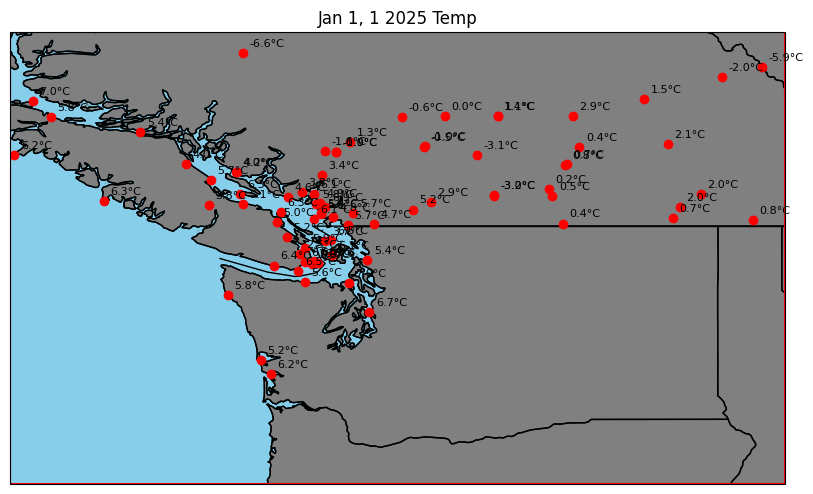

In [11]:
# Define the bounding box (lon_min, lon_max, lat_min, lat_max)
geo_box = [-128, -116, 45, 52]  # Example: part of Washington State

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.LAND, color='gray')
ax.add_feature(cfeature.OCEAN, color="skyblue")

# Set map extent to the geo box
ax.set_extent(geo_box, crs=ccrs.PlateCarree())

# Draw the bounding box
lon_min, lon_max, lat_min, lat_max = geo_box
ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    color='red',
    transform=ccrs.PlateCarree()
)

# Plot each station
for station_id, info in station_data.items():
    name = info['name']
    lon, lat = info['location'].x, info['location'].y
    temp = info['temp_series'].iloc[0]
    if pd.notna(temp):
        ax.plot(lon, lat, marker='o', color='red', markersize=6, transform=ccrs.PlateCarree())
        ax.text(lon + 0.1, lat + 0.1, f"{temp:.1f}°C", fontsize=8, transform=ccrs.PlateCarree())


plt.title("Jan 1, 1 2025 Temp")
plt.show()


#### Animate Sieries Data

---

It's great to see the data on our map. Remember, our data type is a Sieries datatype. This means that we can animate the data and change the station pins based on temperature. Because we have the time stamps we can create an animation using Matplotlib and save it to a gif file type with the pillow package. 

animation saved as temerature_animation.gif


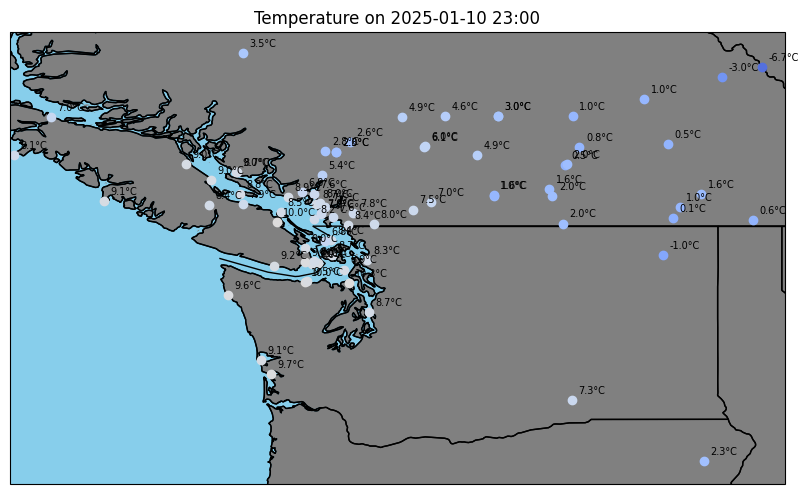

In [15]:
# Setup figure and map
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
geo_box = [-128, -116, 45, 52]
ax.set_extent(geo_box, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.LAND, color='gray')
ax.add_feature(cfeature.OCEAN, color="skyblue")

# Prepare plot objects
scatter_points = []
text_labels = []

# Get the sorted list of timestamps
timestamps = pnw_data['temp'].index  # Shared across all stations

# Initialize the plot
def init():
    return scatter_points + text_labels

# Animation update function
def update(frame_idx):
    global scatter_points, text_labels
    for p in scatter_points + text_labels:
        p.remove()
    scatter_points.clear()
    text_labels.clear()

    current_time = timestamps[frame_idx]
    for info in station_data.values():
        lon, lat = info['location'].x, info['location'].y
        if not (geo_box[0] <= lon <= geo_box[1] and geo_box[2] <= lat <= geo_box[3]):
            continue
        temp_series = info['temp_series']
        temp = temp_series.iloc[frame_idx]
        if pd.notna(temp):
            color = plt.cm.coolwarm((temp + 10) / 40)  # Normalize temp
            pt = ax.plot(lon, lat, marker='o', color=color, markersize=6, transform=ccrs.PlateCarree())[0]
            txt = ax.text(lon + 0.1, lat + 0.1, f"{temp:.1f}°C", fontsize=7, transform=ccrs.PlateCarree())
            scatter_points.append(pt)
            text_labels.append(txt)
    ax.set_title(f"Temperature on {current_time:%Y-%m-%d %H:%M}")
    return scatter_points + text_labels

# Create animation
ani = animation.FuncAnimation(fig, update, frames=len(timestamps), init_func=init, blit=False, interval=1000)

ani.save("temperature_animation.gif", writer="pillow", fps=5)
print('animation saved as temerature_animation.gif')

#### What We've Have Done so Far

---

That was pretty cool—we were able to take temperature data from a Pandas DataFrame, extract a Pandas Series for each station, and animate that data on a map!
You could repeat the same process to visualize any of the other available weather fields (like wind speed, pressure, or precipitation).

You might have noticed that some weather stations flicker during the animation. This happens because the dataset has missing (NaN) values at certain time steps.
Next, we'll address gaps in the data and take a few other cleanup steps to make the dataset more reliable and easier to work with. 

Now, we are ready to begin processing our data to prepare it for use with machine learning. This involves organizing it into a consistent format, handling missing or incomplete values, and ensuring that all features are encoded as numerical values that machine learning algorithms can understand and learn from effectively.

In [16]:
# store all unique time stamps
time_indexes = set()
# itterate the pnd_data keys to add all
for key in pnw_data.keys():
    indexes = pnw_data[key].index
    time_indexes.update(indexes)
time_indexes = sorted(time_indexes)


#### Process Data

---

In the code block above, we retrieved all the unique indexes—in our case, timestamps—and sorted them. Our goal is to create a record (eventually a pandas DataFrame) for each observation in our dataset.

Next, we iterate through each unique timestamp and build a record that captures all the observations at that specific time. This gives us one complete record for each unique timestamp and weather station ID combination. At this stage, we're using plain Python objects (like dictionaries) because these operations are more efficient without the additional computational overhead of working with pandas DataFrames.

You can see that we also added metadata to each record object. This ensures we have rich, contextual data—including the station's location and elevation—which can enhance future analysis or improve the performance of machine learning models that rely on spatial or environmental factors.

#### Indexes

We use indexes in the second two lines of the code below to make our data access more efficient. In the metadata DataFrame, the "USAF" column holds the station IDs we frequently need to reference. Accessing these values repeatedly through filtering can be computationally expensive. To improve performance, we first remove duplicates to ensure each station ID is unique, then set "USAF" as the index. This allows us to quickly access records using dictionary-style lookups. Pandas indexes are a powerful feature that enables fast and readable access to specific records in a DataFrame.

In [17]:
flat_data = []
# make the look up to dict for faster look up, dorp dups
metadata_unique = metadata.drop_duplicates(subset="USAF", keep='first')
meta_lookup = metadata_unique.set_index("USAF").to_dict("index")
for index in time_indexes:
    # diffrent datframse
    # columns are station id
    for station_id in pnw_data[key].columns:

        meta = meta_lookup.get(station_id)
        record = {
            'timestamps': index,
            'station_id': station_id,
            'elivation' : meta['ELEV(M)'],
            'x': meta['x'],
            'y': meta['y'],
            'geometry': meta['geometry']
        }
        for key in pnw_data.keys():
            record[key] = pnw_data[key].at[index, station_id]
        flat_data.append(record)

In [18]:
df = pd.DataFrame(flat_data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1147200 entries, 0 to 1147199
Data columns (total 14 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   timestamps        1147200 non-null  datetime64[ns]
 1   station_id        1147200 non-null  object        
 2   elivation         1146720 non-null  float64       
 3   x                 1147200 non-null  float64       
 4   y                 1147200 non-null  float64       
 5   geometry          1147200 non-null  object        
 6   temp              781064 non-null   float64       
 7   dewtemp           726491 non-null   float64       
 8   pressure          510921 non-null   float64       
 9   winddirection     753926 non-null   float64       
 10  windspeed         772386 non-null   float64       
 11  skycoverage       214667 non-null   float64       
 12  precipitation-1h  72667 non-null    float64       
 13  precipitation-6h  33638 non-null    float6

In [22]:
df

,timestamps,station_id,elivation,x,y,geometry,temp,dewtemp,pressure,winddirection,windspeed,skycoverage,precipitation-1h,precipitation-6h
0,2025-01-01 00:00:00,892570,40.0,-59.150,-75.867,POINT (-59.15 -75.867),-2.1,-3.2,988.6,40.0,7.2,NaN,NaN,NaN
1,2025-01-01 00:00:00,889630,24.0,-56.983,-63.400,POINT (-56.983 -63.4),5.7,-3.5,1003.0,110.0,3.6,7.0,NaN,NaN
2,2025-01-01 00:00:00,890550,208.0,-56.717,-64.233,POINT (-56.717 -64.233),4.3,-5.8,1000.9,310.0,6.7,7.0,NaN,0.0
3,2025-01-01 00:00:00,890590,10.0,-56.683,-63.317,POINT (-56.683 -63.317),1.0,1.0,1008.1,260.0,14.9,7.0,NaN,0.0
4,2025-01-01 00:00:00,892660,115.0,-60.167,-72.200,POINT (-60.167 -72.2),-1.2,-1.4,990.5,350.0,8.2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147195,2025-01-10 23:00:00,718080,36.9,-57.183,51.450,POINT (-57.183 51.45),1.0,-3.0,994.1,10.0,7.2,NaN,NaN,NaN
1147196,2025-01-10 23:00:00,715580,29.0,-56.100,51.383,POINT (-56.1 51.383),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1147197,2025-01-10 23:00:00,713130,37.8,-63.600,50.283,POINT (-63.6 50.283),-2.0,-7.0,1003.7,360.0,4.1,0.0,NaN,NaN
1147198,2025-01-10 23:00:00,714210,589.0,-63.283,51.867,POINT (-63.283 51.867),-7.5,-10.1,1006.5,10.0,5.7,NaN,NaN,NaN


#### Closer Look

Sometimes, it can be helpful to Visualize our data so we can see how the missing values are distributed across the data set. 

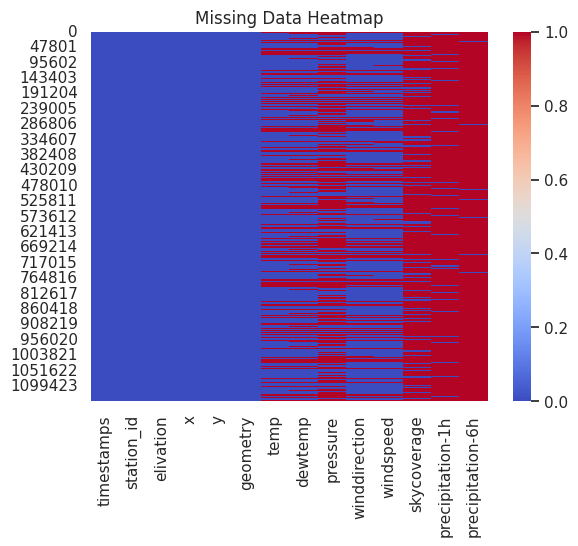

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
tips = sns.load_dataset("tips")

sns.heatmap(df.isnull(),  cmap="coolwarm", cbar=True)

plt.title("Missing Data Heatmap")
plt.show()

#### Dealing with missing Data

---

Let’s think through how we want to handle missing values in our weather dataset.

First, we’ll visualize the data to better understand the missing values. Keep in mind that this dataset currently only covers 10 days, so the sample size is limited. Also remember: this is weather data, so we can make domain-specific assumptions to fill in the gaps.

* Here are our assumptions and strategies for dealing with missing (NaN) values:
* Windspeed and Wind Direction: If these are missing, we’ll assume the wind was not blowing, so we’ll set missing values to 0.
* Sky Coverage and Precipitation: If NaN, we’ll assume clear skies and no rain, so we’ll also set these to 0.
* Dew Temperature and Air Temperature: For these, setting to 0 would distort the data. Instead, we’ll fill missing values using the median of each column, which helps preserve the overall distribution without being affected by outliers.

In [36]:
# Replace missing values
df.fillna({
    'windspeed': 0, 
    'winddirection':  0,
    'skycoverage' : 0,
    'precipitation-1h' : 0,
    'precipitation-6h' : 0,
}, inplace=True)

# Fill temperature columns with median values
df.fillna({
    'temp' : df['temp'].median(),
    'dewtemp' : df['dewtemp'].median(),
    'pressure' : df['pressure'].median(),
}, inplace=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1147200 entries, 0 to 1147199
Data columns (total 14 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   timestamps        1147200 non-null  datetime64[ns]
 1   station_id        1147200 non-null  object        
 2   elivation         1146720 non-null  float64       
 3   x                 1147200 non-null  float64       
 4   y                 1147200 non-null  float64       
 5   geometry          1147200 non-null  object        
 6   temp              1147200 non-null  float64       
 7   dewtemp           1147200 non-null  float64       
 8   pressure          1147200 non-null  float64       
 9   winddirection     1147200 non-null  float64       
 10  windspeed         1147200 non-null  float64       
 11  skycoverage       1147200 non-null  float64       
 12  precipitation-1h  1147200 non-null  float64       
 13  precipitation-6h  1147200 non-null  float6

We can see that we have 1147200 records and 1147200 non-null values for all rows. We are ready. To be sure, we can see it in our heat map.

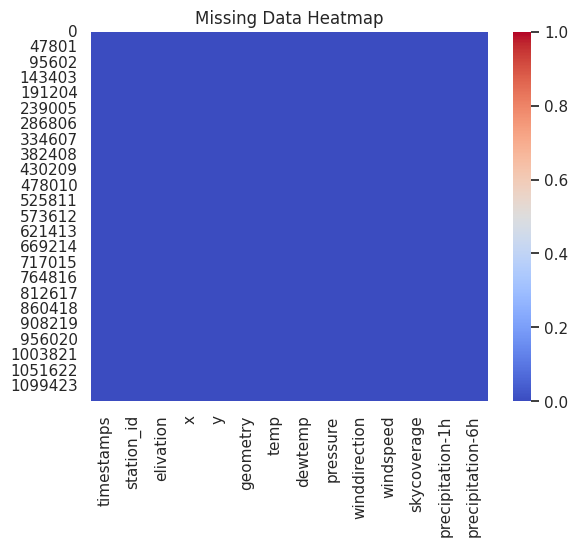

In [35]:
sns.set_theme(style="whitegrid")
tips = sns.load_dataset("tips")

sns.heatmap(df.isnull(),  cmap="coolwarm", cbar=True)

plt.title("Missing Data Heatmap")
plt.show()

#### Recap

---

We've covered a lot and successfully completed a real-world data-cleaning and preparation project for weather analysis. Here's what we accomplished:

* Downloaded weather data from the NOAA database.
* Displayed the data on a map to visualize station locations.
* Created a time series and even animated weather conditions over time.
* Transformed the data from a wide format into individual observations (long format) for analysis.

Handled missing values by:

* Filling in values for windspeed, direction, sky coverage, and precipitation where appropriate.
* Using median values for temperature and dew point when data was missing.
* Dropping records only when filling wasn't reasonable or meaningful.

#### Reverences

---

* Global Hourly—Integrated Surface Database (ISD). (2021, March 17). National Centers for Environmental Information (NCEI). https://www.ncei.noaa.gov/products/land-based-station/integrated-surface-database
* How to Set Up a Virtual Environment in Python – And Why It’s Useful. (2022, April 11). freeCodeCamp.Org. https://www.freecodecamp.org/news/how-to-setup-virtual-environments-in-python/
* Introduction—Cartopy 0.24.1 documentation. (n.d.). Retrieved May 1, 2025, from https://scitools.org.uk/cartopy/docs/latest/
* Isd-fetch/README.md at main · CyrilJl/isd-fetch. (n.d.). GitHub. Retrieved April 29, 2025, from https://github.com/CyrilJl/isd-fetch/blob/main/README.md
* pandas—Python Data Analysis Library. (n.d.). Retrieved April 29, 2025, from https://pandas.pydata.org/
* seaborn.lineplot—Seaborn 0.13.2 documentation. (n.d.). Retrieved April 29, 2025, from https://seaborn.pydata.org/generated/seaborn.lineplot.html
* The Ultimate Guide to the Pandas Library for Data Science in Python. (2020, July 8). freeCodeCamp.Org. https://www.freecodecamp.org/news/the-ultimate-guide-to-the-pandas-library-for-data-science-in-python/

